# Incident Resolution & SLA Performance Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maria-antonia-analytics/data-analysis-portfolio/blob/main/04-python-incident-sla-analysis/notebooks/incident_sla_analysis.ipynb)

**Goal:** use Python to answer the questions about the IT incident database that were hard to answer with SQL alone in [project 2](../../02-sql-incident-user-analysis).

**Data:** the same SQLite database as project 2, `it_incidents.db`: 2,031 incidents from 440 employees, January to June 2026, in five tables. The data is synthetic. I generated it in Python to mimic a mid-sized company's incident log, and it contains no real company or personal data.

Project 2 found *which* teams and users have problems. This notebook looks at *how* resolution performance behaves:

1. Can the data be trusted, and what does the SLA clock actually measure?
2. How long do incidents really take? (distributions, not averages)
3. Where does the SLA break, and is the comparison between teams fair?
4. How badly do breaches miss their target?
5. Is the problem team overloaded?
6. Do fixes stick?
7. Which differences are real and which are noise?

The loading and KPI functions live in `src/incident_kpis.py` so they can be reused and tested outside the notebook.

In [1]:
# Running in Google Colab? This cell downloads the project files first.
# On your own computer it does nothing.
import os
import subprocess
import sys

if "google.colab" in sys.modules and not os.path.exists("../src"):
    subprocess.run(["git", "clone", "-q",
                    "https://github.com/maria-antonia-analytics/data-analysis-portfolio.git"], check=True)
    os.chdir("data-analysis-portfolio/04-python-incident-sla-analysis/notebooks")

In [2]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, "../src")
import incident_kpis as kpi

IMAGES = Path("../images")
IMAGES.mkdir(exist_ok=True)

df = kpi.load_incidents()
print(f"{len(df):,} incidents, {df.shape[1]} columns, "
      f"{df.opened_at.min():%d %b %Y} to {df.opened_at.max():%d %b %Y}")
df.head(3)

2,031 incidents, 22 columns, 01 Jan 2026 to 30 Jun 2026


,incident_id,opened_at,resolved_at,category,severity,reopened,user_id,location,device_os,hire_date,department,agent_id,agent_name,team,target_hours,resolution_hours,sla_met,sla_ratio,hours_over,opened_date,opened_weekday,resolved_weekday
0,1,2026-01-01 12:55:00,2026-01-03 08:35:00,Login / MFA,P4,False,1183,Remote,macOS,2022-10-29,Customer Support,5,E. Haddad,Service Desk,72.0,43.666667,True,0.606481,0.0,2026-01-01,Thursday,Saturday
1,2,2026-01-01 12:42:00,2026-01-01 19:14:00,Access Request,P3,False,1357,HQ Office,Windows,2024-04-20,Customer Support,2,B. Okafor,Service Desk,24.0,6.533333,True,0.272222,0.0,2026-01-01,Thursday,Thursday
2,3,2026-01-01 16:31:00,2026-01-01 19:53:00,Access Request,P2,False,1001,Branch Office,Windows,2023-11-14,Marketing,1,A. Chen,Service Desk,8.0,3.366667,True,0.420833,0.0,2026-01-01,Thursday,Thursday


In [3]:
# One look for all charts: fixed colours per team, light grid, no chart junk.
BLUE, ORANGE, AQUA, YELLOW, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#c3c2b7"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"
TEAM_COLOURS = {"Service Desk": BLUE, "Infrastructure": ORANGE, "Applications": AQUA}
SEVERITIES = ["P1", "P2", "P3", "P4"]

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": GREY, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "axes.axisbelow": True,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.size": 10, "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

## 1. Data quality and the SLA clock

Two checks before any analysis: are there rows that would break the numbers, and what does "resolution time" measure in this data?

In [4]:
kpi.quality_checks(df).to_frame()

,rows
missing values,0
duplicate incident ids,0
resolved before opened,0
opened before hire date,0
opened on a weekend,0


In [5]:
# The headline KPIs should match project 2 (24.1 h, 75.9%, 6.8%)
kpi.kpi_summary(df).to_frame("all incidents")

,all incidents
incidents,2031.0
mean hours,24.1
median hours,16.2
90th percentile hours,51.4
SLA compliance %,75.9
SLA breaches,489.0
hours over target,7449.0
reopen rate %,6.8


In [6]:
# When are tickets opened, and when are they resolved?
weekend = df.resolved_weekday.isin(["Saturday", "Sunday"])
night = (df.resolved_at.dt.hour < 8) | (df.resolved_at.dt.hour >= 18)

print(f"Opened:   weekdays only, between {df.opened_at.dt.hour.min()}:00 and {df.opened_at.dt.hour.max() + 1}:00")
print(f"Resolved on a weekend:                 {weekend.sum():>4} ({weekend.mean():.1%})")
print(f"Resolved on a weekday outside 08-18 h: {(night & ~weekend).sum():>4} ({(night & ~weekend).mean():.1%})")
pd.crosstab(df.opened_weekday, df.resolved_weekday)

Opened:   weekdays only, between 8:00 and 18:00
Resolved on a weekend:                  334 (16.4%)
Resolved on a weekday outside 08-18 h: 1042 (51.3%)


resolved_weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
opened_weekday,,,,,,,
Monday,177,212,81,25,8,6,4
Tuesday,3,133,156,62,13,5,3
Wednesday,2,1,120,191,49,18,1
Thursday,8,2,0,126,177,56,15
Friday,15,6,1,2,127,182,44


**What this tells us**

- All five checks return zero, and the headline KPIs match project 2 (24.1 hours, 75.9% SLA compliance, 6.8% reopened), so the Python table is the same data the SQL queries used.
- Tickets are only *opened* on weekdays between 08:00 and 18:00, but they are *resolved* at any time: 334 (16.4%) on a weekend and another 1,042 (51.3%) on a weekday outside 08:00 to 18:00. Of the 377 tickets opened on a Friday, 226 (60%) were closed on Saturday or Sunday.
- So the SLA clock in this data measures **elapsed calendar hours** and never pauses. Every result below uses that definition. A service desk that only works business hours would need a business-hours clock, and its numbers would look different.

## 2. How long do incidents really take?

Project 2 reported an average of 24.1 hours. An average hides the shape of the data, so this section looks at the whole distribution.

In [7]:
percentiles = (df.groupby("severity")["resolution_hours"]
               .describe(percentiles=[0.5, 0.9, 0.95])
               [["count", "mean", "50%", "90%", "95%", "max"]])
percentiles.loc["All"] = df["resolution_hours"].describe(percentiles=[0.5, 0.9, 0.95])[percentiles.columns]
percentiles["target"] = df.groupby("severity")["target_hours"].first()
percentiles.round(1)

,count,mean,50%,90%,95%,max,target
severity,,,,,,,
P1,104.0,2.6,2.0,5.1,7.1,13.2,4.0
P2,335.0,7.9,6.4,14.9,19.2,29.8,8.0
P3,978.0,19.4,15.5,37.5,45.7,113.8,24.0
P4,614.0,44.1,35.0,80.9,106.6,369.5,72.0
All,2031.0,24.1,16.2,51.4,68.0,369.5,NaN


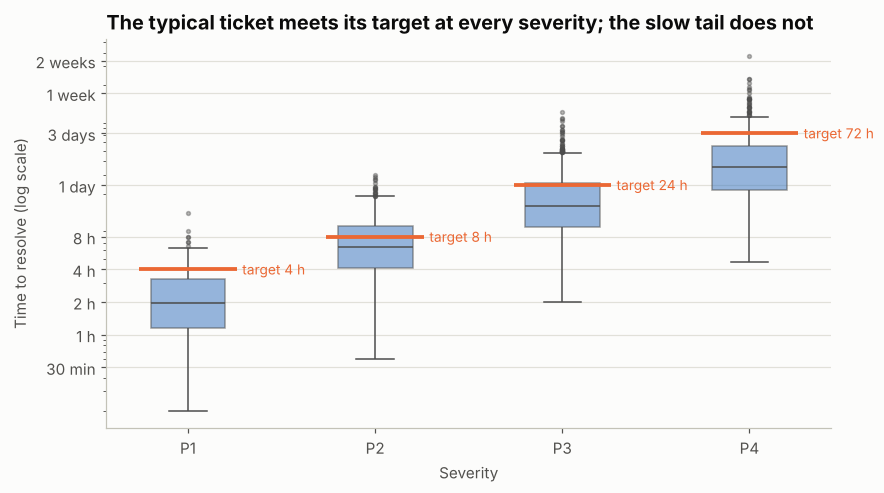

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
sns.boxplot(data=df, x="severity", y="resolution_hours", order=SEVERITIES, color=BLUE, width=0.4,
            fliersize=2.5, linewidth=1, boxprops={"alpha": 0.55}, flierprops={"markerfacecolor": MUTED, "alpha": 0.4}, ax=ax)
for i, sev in enumerate(SEVERITIES):
    target = df.loc[df.severity == sev, "target_hours"].iloc[0]
    ax.hlines(target, i - 0.26, i + 0.26, color=ORANGE, linewidth=2.5)
    ax.text(i + 0.29, target, f"target {target:g} h", color=ORANGE, va="center", fontsize=9)
ax.set_yscale("log")
ax.set_yticks([0.5, 1, 2, 4, 8, 24, 72, 168, 336])
ax.set_yticklabels(["30 min", "1 h", "2 h", "4 h", "8 h", "1 day", "3 days", "1 week", "2 weeks"])
ax.set_xlabel("Severity")
ax.set_ylabel("Time to resolve (log scale)")
ax.set_title("The typical ticket meets its target at every severity; the slow tail does not")
fig.savefig(IMAGES / "01_resolution_time_by_severity.png")
plt.show()

**What this tells us**

- The distribution is strongly skewed. The mean is 24.1 hours but the median is 16.2 hours: half of all tickets are closed in about two thirds of the "average" time. The mean is pulled up by a slow tail. 10% of tickets take longer than 51.4 hours, 5% take longer than 68 hours, and the slowest took 369.5 hours (more than 15 days).
- At every severity the median ticket beats its target (2.0 h against 4 h for P1, 6.4 h against 8 h for P2, 15.5 h against 24 h for P3, 35.0 h against 72 h for P4). At every severity the 90th percentile misses it.
- The SLA problem is therefore a tail problem. Reporting the median and the 90th percentile next to the average would show this, and the average alone does not.

## 3. Where does the SLA break?

Project 2 showed that Infrastructure misses its SLA most often. Two follow-up questions: which exact combinations of category and severity fail, and is Infrastructure only worse because it gets more urgent tickets with tighter targets?

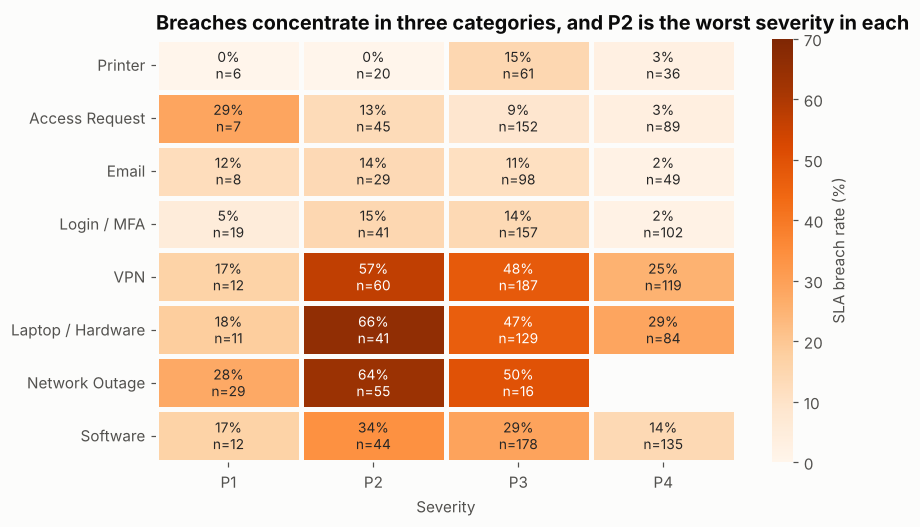

In [9]:
order = (df.groupby(["team", "category"])["sla_met"].mean().reset_index()
         .sort_values(["team", "sla_met"], ascending=[False, False])["category"])
breach_rate = (1 - df.pivot_table(index="category", columns="severity", values="sla_met", aggfunc="mean")).loc[order] * 100
counts = df.pivot_table(index="category", columns="severity", values="sla_met", aggfunc="size").loc[order]
labels = breach_rate.round(0).astype("Int64").astype(str) + "%\nn=" + counts.astype("Int64").astype(str)
labels = labels.where(counts.notna(), "")

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.heatmap(breach_rate, annot=labels, fmt="", cmap="Oranges", vmin=0, vmax=70, linewidths=2, linecolor="#fcfcfb",
            cbar_kws={"label": "SLA breach rate (%)"}, annot_kws={"fontsize": 9}, ax=ax)
ax.set_xlabel("Severity")
ax.set_ylabel("")
ax.grid(False)
ax.set_title("Breaches concentrate in three categories, and P2 is the worst severity in each")
fig.savefig(IMAGES / "02_breach_rate_heatmap.png")
plt.show()

In [10]:
# Is Infrastructure worse only because of its ticket mix?
print(pd.crosstab(df.team, df.severity, normalize="index").mul(100).round(1).to_string(), "\n")
kpi.standardised_compliance(df, "team")

severity         P1    P2    P3    P4
team                                 
Applications    3.3  11.9  48.2  36.6
Infrastructure  7.0  21.0  44.7  27.3
Service Desk    4.4  14.7  50.9  30.0 



,raw %,same severity mix %
team,,
Applications,76.2,75.2
Infrastructure,57.1,57.9
Service Desk,91.1,91.1


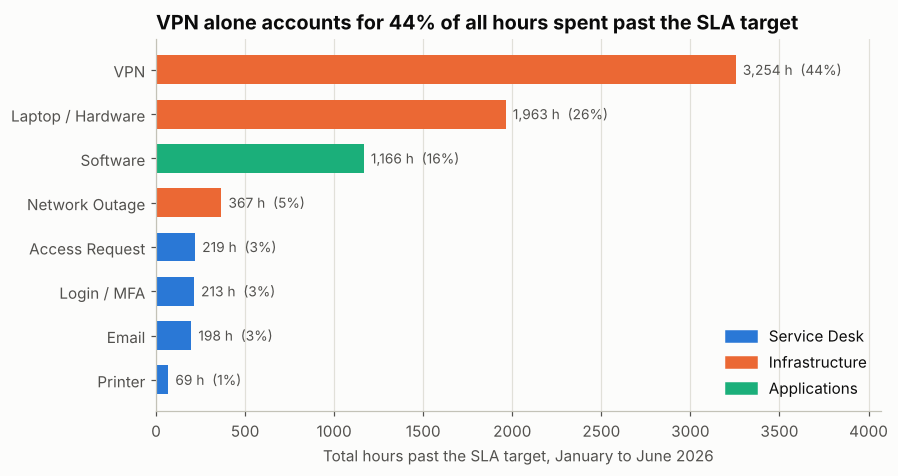

,team,breaches,hours_over,share of breaches %,share of hours over %
category,,,,,
VPN,Infrastructure,155,3254.0,32.0,44.0
Laptop / Hardware,Infrastructure,113,1963.0,23.0,26.0
Software,Applications,88,1166.0,18.0,16.0
Network Outage,Infrastructure,51,367.0,10.0,5.0
Access Request,Service Desk,24,219.0,5.0,3.0
Login / MFA,Service Desk,31,213.0,6.0,3.0
Email,Service Desk,17,198.0,4.0,3.0
Printer,Service Desk,10,69.0,2.0,1.0


In [11]:
# Counting breaches treats a 1-hour miss and a 5-day miss the same.
# Hours over target shows where users actually waited.
by_category = (df.groupby(["category", "team"])
               .agg(breaches=("sla_met", lambda s: (~s).sum()), hours_over=("hours_over", "sum"))
               .reset_index().sort_values("hours_over"))
by_category["share of breaches %"] = (by_category.breaches / by_category.breaches.sum() * 100).round(1)
by_category["share of hours over %"] = (by_category.hours_over / by_category.hours_over.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(by_category.category, by_category.hours_over, color=by_category.team.map(TEAM_COLOURS), height=0.65)
for y, (hours, share) in enumerate(zip(by_category.hours_over, by_category["share of hours over %"])):
    ax.text(hours + 40, y, f"{hours:,.0f} h  ({share:.0f}%)", va="center", fontsize=9, color=MUTED)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in TEAM_COLOURS.values()],
          labels=list(TEAM_COLOURS), frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlim(0, by_category.hours_over.max() * 1.25)
ax.set_xlabel("Total hours past the SLA target, January to June 2026")
ax.set_title("VPN alone accounts for 44% of all hours spent past the SLA target")
fig.savefig(IMAGES / "03_hours_over_target.png")
plt.show()

by_category.sort_values("hours_over", ascending=False).round(0).set_index("category")

In [12]:
team_over = df.groupby("team").agg(breaches=("sla_met", lambda s: (~s).sum()), hours_over=("hours_over", "sum"))
(team_over / team_over.sum() * 100).round(1).add_prefix("share of ")

,share of breaches,share of hours_over
team,,
Applications,18.0,15.7
Infrastructure,65.2,75.0
Service Desk,16.8,9.4


**What this tells us**

- Breaches concentrate in three categories, all owned by Infrastructure: VPN, Laptop / Hardware and Network Outage. P2 is the worst severity in each: 66% of Laptop / Hardware P2 tickets breach (n=41), 64% of Network Outage P2 (n=55) and 57% of VPN P2 (n=60). Cells with very few tickets, such as Access Request P1 (n=7), are too small to read anything into.
- The ticket mix is not the explanation. Infrastructure does get more urgent work (28% of its tickets are P1 or P2, against 19% for Service Desk and 15% for Applications), but giving every team the same severity mix moves Infrastructure from 57.1% to only 57.9%. It is slower at every severity.
- Counting breaches understates the problem. Infrastructure has 65.2% of the breaches but 75.0% of the 7,449 hours spent past target. VPN alone is 3,254 hours (44%), and VPN plus Laptop / Hardware is 70%.
- Network Outage has some of the worst breach rates but only 367 hours over target (5%), because it has few tickets and short targets. Ranked by user waiting time, VPN is the priority.

## 4. How badly do breaches miss?

`sla_ratio` is the time a ticket took divided by its target. A value of 1.0 means it used exactly its target, and 1.25 means it ran 25% over. This puts a 4-hour P1 and a 72-hour P4 on the same scale.

In [13]:
bands = pd.cut(df.sla_ratio, [0, 0.75, 1, 1.25, 2, np.inf],
               labels=["Comfortable (under 75% of target)", "At risk (75-100%)", "Near miss (up to 25% over)",
                       "Clear miss (25-100% over)", "Severe (more than double)"])
band_table = bands.value_counts().sort_index().to_frame("incidents")
band_table["% of all"] = (band_table.incidents / len(df) * 100).round(1)
band_table["% of breaches"] = (band_table.incidents / (~df.sla_met).sum() * 100).round(1).where(band_table.index.str.contains("miss|Severe"))
band_table

,incidents,% of all,% of breaches
sla_ratio,,,
Comfortable (under 75% of target),1257,61.9,NaN
At risk (75-100%),285,14.0,NaN
Near miss (up to 25% over),175,8.6,35.8
Clear miss (25-100% over),226,11.1,46.2
Severe (more than double),88,4.3,18.0


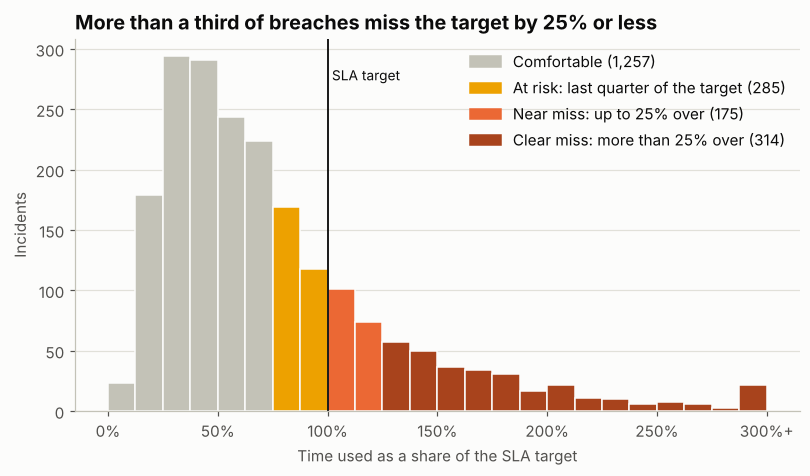

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
edges = np.arange(0, 3.01, 0.125)
n, _, patches = ax.hist(df.sla_ratio.clip(upper=2.99), bins=edges, edgecolor="#fcfcfb", linewidth=1)
for left, patch in zip(edges, patches):
    patch.set_facecolor(GREY if left < 0.75 else YELLOW if left < 1 else ORANGE if left < 1.25 else "#a8431c")
ax.axvline(1, color=INK, linewidth=1.2)
ax.text(1.02, n.max() * 0.97, "SLA target", fontsize=9, va="top")
band_colours = [GREY, YELLOW, ORANGE, "#a8431c"]
band_counts = [band_table.incidents.iloc[0], band_table.incidents.iloc[1], band_table.incidents.iloc[2], band_table.incidents.iloc[3:].sum()]
band_names = ["Comfortable", "At risk: last quarter of the target", "Near miss: up to 25% over", "Clear miss: more than 25% over"]
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in band_colours],
          labels=[f"{name} ({count:,})" for name, count in zip(band_names, band_counts)], frameon=False, loc="upper right")
ax.set_xticks([0, 0.5, 1, 1.5, 2, 2.5, 3])
ax.set_xticklabels(["0%", "50%", "100%", "150%", "200%", "250%", "300%+"])
ax.set_xlabel("Time used as a share of the SLA target")
ax.set_ylabel("Incidents")
ax.set_title("More than a third of breaches miss the target by 25% or less")
fig.savefig(IMAGES / "04_sla_ratio_distribution.png")
plt.show()

In [15]:
# What if every near miss had been caught in time?
near_miss = (df.sla_ratio > 1) & (df.sla_ratio <= 1.25)
what_if = pd.DataFrame({
    "actual %": df.groupby("team")["sla_met"].mean() * 100,
    "near misses": near_miss.groupby(df.team).sum(),
    "if near misses were on time %": (df.sla_met | near_miss).groupby(df.team).mean() * 100,
})
what_if.loc["All"] = [df.sla_met.mean() * 100, near_miss.sum(), (df.sla_met | near_miss).mean() * 100]
what_if.round(1)

,actual %,near misses,if near misses were on time %
team,,,
Applications,76.2,41.0,87.3
Infrastructure,57.1,92.0,69.4
Service Desk,91.1,42.0,95.6
All,75.9,175.0,84.5


In [16]:
# How far over target is the typical breach in each team?
df[~df.sla_met].groupby("team")["sla_ratio"].describe(percentiles=[0.5])[["count", "50%", "max"]].rename(
    columns={"count": "breaches", "50%": "median ratio", "max": "worst ratio"}).round(2)

,breaches,median ratio,worst ratio
team,,,
Applications,88.0,1.28,3.31
Infrastructure,319.0,1.52,5.13
Service Desk,82.0,1.24,4.10


**What this tells us**

- 175 of the 489 breaches (35.8%) missed the target by 25% or less. Another 285 tickets finished in the last quarter of their target and only just made it. Together that is 460 tickets (22.6% of all incidents) decided within a quarter of the target on either side.
- If every near miss had been caught, overall compliance would rise from 75.9% to 84.5%. An alert when a ticket reaches 75% of its target is the cheapest improvement available.
- That alert would not fix Infrastructure. Its compliance would rise from 57.1% to 69.4%, still the lowest. The typical Infrastructure breach runs 52% over target, against 24% for Service Desk and 28% for Applications, and 88 tickets across all teams took more than double their target.

## 5. Is Infrastructure overloaded?

SQL can count tickets per agent. It is much harder to ask "how many tickets were open at the same time?" In Pandas this is a running total: every ticket adds 1 when it opens and subtracts 1 when it is resolved.

In [17]:
agents_per_team = df.groupby("team")["agent_id"].nunique()
backlog = kpi.open_backlog(df, "team").loc["2026-01-08":"2026-06-30"]   # skip the first week while the queue fills

workload = pd.DataFrame({
    "agents": agents_per_team,
    "incidents": df.groupby("team").size(),
    "incidents per agent": (df.groupby("team").size() / agents_per_team).round(0),
    "median hours per ticket": df.groupby("team")["resolution_hours"].median().round(1),
    "avg open tickets": backlog.mean().round(1),
    "avg open per agent": (backlog.mean() / agents_per_team).round(2),
    "peak open tickets": backlog.max().astype(int),
})
workload

,agents,incidents,incidents per agent,median hours per ticket,avg open tickets,avg open per agent,peak open tickets
team,,,,,,,
Applications,2,369,184.0,20.2,2.4,1.18,7
Infrastructure,3,743,248.0,22.2,5.4,1.81,13
Service Desk,5,919,184.0,12.5,3.5,0.71,11


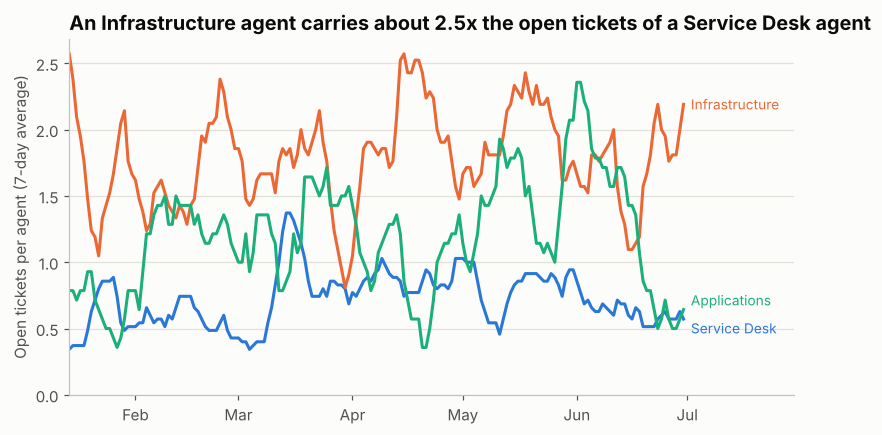

In [18]:
per_agent = (backlog / agents_per_team).rolling(7, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for team, colour in TEAM_COLOURS.items():
    ax.plot(per_agent.index, per_agent[team], color=colour, linewidth=2)
    nudge = {"Applications": 0.07, "Service Desk": -0.07}.get(team, 0)   # keep the two close labels apart
    ax.text(per_agent.index[-1] + pd.Timedelta(days=2), per_agent[team].iloc[-1] + nudge, team, color=colour, va="center", fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_ylim(0)
ax.set_xlim(per_agent.index[6], per_agent.index[-1] + pd.Timedelta(days=30))
ax.set_ylabel("Open tickets per agent (7-day average)")
ax.set_title("An Infrastructure agent carries about 2.5x the open tickets of a Service Desk agent")
fig.savefig(IMAGES / "05_open_backlog_per_agent.png")
plt.show()

In [19]:
# Does the pressure build during the period?
(backlog / agents_per_team).resample("MS").mean().round(2).rename_axis("month").rename(index=lambda d: d.strftime("%b"))

team,Applications,Infrastructure,Service Desk
month,,,
Jan,0.69,1.78,0.55
Feb,1.27,1.71,0.56
Mar,1.32,1.55,0.81
Apr,0.98,2.04,0.94
May,1.52,1.97,0.75
Jun,1.17,1.79,0.61


In [20]:
# If Infrastructure breaches because it is overloaded, tickets that arrive when the
# queue is long should breach more often than tickets that arrive when it is short.
infra = df[df.team == "Infrastructure"].copy()
infra["queue_on_arrival"] = kpi.open_when_opened(infra)
infra["queue"] = pd.cut(infra.queue_on_arrival, [0, 4, 6, 8, 100], labels=["1-4 open", "5-6 open", "7-8 open", "9 or more"])

print(f"Correlation between queue length on arrival and SLA ratio: {infra.queue_on_arrival.corr(infra.sla_ratio):.2f}")
infra.groupby("queue", observed=True).agg(
    incidents=("sla_met", "size"), sla_compliance=("sla_met", "mean"),
    median_hours=("resolution_hours", "median")).round(3)

Correlation between queue length on arrival and SLA ratio: 0.02


,incidents,sla_compliance,median_hours
queue,,,
1-4 open,147,0.544,21.217
5-6 open,189,0.624,23.767
7-8 open,182,0.571,21.600
9 or more,225,0.542,22.200


Monday:            19.7 incidents per day, 4.6 VPN
Tuesday to Friday: 14.7 incidents per day, 2.5 VPN


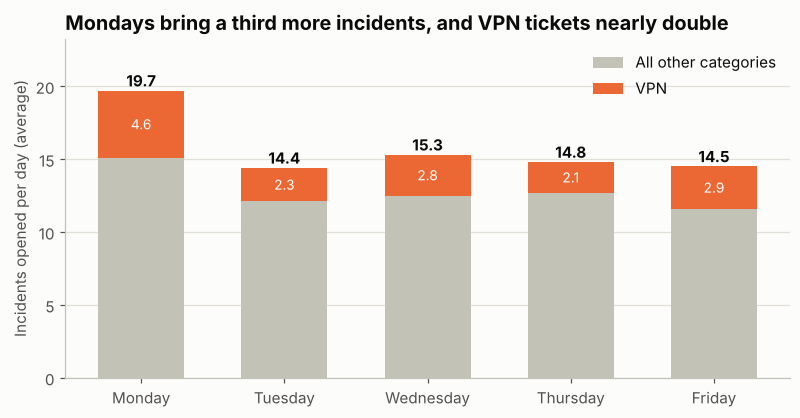

,days,incidents,VPN,incidents per day,VPN per day,other per day,VPN share %
opened_weekday,,,,,,,
Monday,26,513,119,19.7,4.6,15.1,23.2
Tuesday,26,375,60,14.4,2.3,12.1,16.0
Wednesday,25,382,69,15.3,2.8,12.5,18.1
Thursday,26,384,55,14.8,2.1,12.7,14.3
Friday,26,377,75,14.5,2.9,11.6,19.9


In [21]:
# When does the work arrive?
days_in_period = df.groupby("opened_weekday", observed=True)["opened_date"].nunique()
arrivals = pd.DataFrame({
    "days": days_in_period,
    "incidents": df.groupby("opened_weekday", observed=True).size(),
    "VPN": df[df.category == "VPN"].groupby("opened_weekday", observed=True).size(),
})
arrivals["incidents per day"] = (arrivals.incidents / arrivals.days).round(1)
arrivals["VPN per day"] = (arrivals.VPN / arrivals.days).round(1)
arrivals["other per day"] = arrivals["incidents per day"] - arrivals["VPN per day"]
arrivals["VPN share %"] = (arrivals.VPN / arrivals.incidents * 100).round(1)

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(arrivals.index, arrivals["other per day"], color=GREY, width=0.6, label="All other categories")
ax.bar(arrivals.index, arrivals["VPN per day"], bottom=arrivals["other per day"], color=ORANGE, width=0.6, label="VPN")
for x, (total, vpn) in enumerate(zip(arrivals["incidents per day"], arrivals["VPN per day"])):
    ax.text(x, total + 0.3, f"{total:.1f}", ha="center", fontsize=10, fontweight="bold")
    ax.text(x, total - vpn / 2, f"{vpn:.1f}", ha="center", va="center", fontsize=9, color="white")
ax.legend(frameon=False, loc="upper right")
ax.set_ylim(0, arrivals["incidents per day"].max() * 1.18)
ax.set_ylabel("Incidents opened per day (average)")
ax.set_title("Mondays bring a third more incidents, and VPN tickets nearly double")
fig.savefig(IMAGES / "06_incidents_by_weekday.png")
plt.show()

monday = arrivals.loc["Monday"]
rest = arrivals.drop("Monday").sum()
print(f"Monday:            {monday.incidents / monday.days:.1f} incidents per day, {monday.VPN / monday.days:.1f} VPN")
print(f"Tuesday to Friday: {rest.incidents / rest.days:.1f} incidents per day, {rest.VPN / rest.days:.1f} VPN")
arrivals

In [22]:
# Does the Monday peak hurt SLA compliance?
df.groupby("opened_weekday", observed=True).agg(
    sla_compliance=("sla_met", "mean"), median_hours=("resolution_hours", "median")).round(3)

,sla_compliance,median_hours
opened_weekday,,
Monday,0.747,16.067
Tuesday,0.755,16.350
Wednesday,0.762,16.717
Thursday,0.781,16.942
Friday,0.756,15.183


**What this tells us**

- Infrastructure carries the heaviest load: 248 incidents per agent in six months against 184 for the other two teams, and each ticket stays open almost twice as long as a Service Desk ticket (median 22.2 h against 12.5 h). The result is 1.81 open tickets per agent on an average day, about 2.5 times the Service Desk's 0.71.
- But load does not explain the breaches. Infrastructure tickets that arrived when the queue was short (1 to 4 open) met the SLA 54.4% of the time, and tickets that arrived when it was longest (9 or more open) met it 54.2% of the time. The correlation between queue length and time used is 0.02. The backlog is also not growing: it peaks in April (2.04 per agent) and falls back.
- So Infrastructure is slow whether it is busy or quiet. That points to how these tickets are worked (waiting for parts, vendors or access, unclear diagnosis steps) more than to headcount. Adding an agent would lower the load per person, but this data gives no evidence that it would lower the breach rate.
- Mondays bring 19.7 incidents a day against 14.7 from Tuesday to Friday (34% more), and VPN tickets nearly double (4.6 a day against 2.5). The teams absorb the peak: Monday SLA compliance is 74.7%, not meaningfully different from other days (tested in section 7).

## 6. Do fixes stick?

The database has a `reopened` flag. A second signal is the **repeat contact**: the same user opening a new incident in the same category within 14 days. A user whose VPN "fix" did not hold may open a new ticket instead of reopening the old one.

In [23]:
df["repeat_contact"] = kpi.repeat_contacts(df, window_days=14)

print(f"Reopened tickets:          {df.reopened.sum():>4} ({df.reopened.mean():.1%})")
print(f"Repeat contacts (14 days): {df.repeat_contact.sum():>4} ({df.repeat_contact.mean():.1%})")
print(f"Either signal:             {(df.reopened | df.repeat_contact).sum():>4} ({(df.reopened | df.repeat_contact).mean():.1%})")
print(f"Both signals on one ticket:{(df.reopened & df.repeat_contact).sum():>4}")

sticking = df.groupby("category").agg(
    incidents=("incident_id", "size"),
    reopen_rate=("reopened", "mean"),
    repeat_contact_rate=("repeat_contact", "mean"),
    users_with_repeat=("user_id", lambda s: s[df.loc[s.index, "repeat_contact"]].nunique()),
)
sticking[["reopen_rate", "repeat_contact_rate"]] = (sticking[["reopen_rate", "repeat_contact_rate"]] * 100).round(1)
sticking.sort_values("repeat_contact_rate", ascending=False)

Reopened tickets:           138 (6.8%)
Repeat contacts (14 days):  204 (10.0%)
Either signal:              324 (16.0%)
Both signals on one ticket:  18


,incidents,reopen_rate,repeat_contact_rate,users_with_repeat
category,,,,
VPN,378,6.9,14.0,31
Software,369,6.0,12.5,33
Access Request,293,5.8,11.3,25
Login / MFA,319,8.8,10.3,26
Email,184,8.7,6.5,11
Laptop / Hardware,265,3.8,6.0,15
Network Outage,100,8.0,5.0,4
Printer,123,8.9,4.9,6


In [24]:
# Heavy users open many tickets, so some repeats happen by chance.
# Shuffle the categories among each user's own tickets 2,000 times and count the repeats each time.
pd.Series(kpi.repeat_contacts_by_chance(df, window_days=14)).to_frame("value")

,value
observed repeat contacts,204
expected by chance,213.2
chance range (95%),193 to 232
share of shuffles at or above observed,0.83


In [25]:
# The repeat rate simply follows how many tickets each user has in a category
volume = df.groupby("category").agg(
    tickets_per_user=("user_id", lambda s: len(s) / s.nunique()),
    repeat_contact_rate=("repeat_contact", "mean"))
print(f"Correlation between tickets per user and repeat rate: {volume.tickets_per_user.corr(volume.repeat_contact_rate):.2f}")
volume.round(3).sort_values("tickets_per_user", ascending=False)

Correlation between tickets per user and repeat rate: 0.92


,tickets_per_user,repeat_contact_rate
category,,
VPN,1.948,0.140
Software,1.809,0.125
Login / MFA,1.661,0.103
Access Request,1.584,0.113
Laptop / Hardware,1.577,0.060
Email,1.405,0.065
Printer,1.323,0.049
Network Outage,1.266,0.050


**What this tells us**

- A 14-day repeat contact looked like a useful second quality signal: 204 incidents (10.0%), more than the 138 reopened tickets, and highest for VPN (14.0%) and Software (12.5%).
- It does not survive a check against chance. Shuffling the categories among each user's own tickets gives 213 repeat contacts on average, with a 95% range of 193 to 232. The real count of 204 sits inside that range. Users are not coming back with the same problem sooner than they would by coincidence.
- The repeat rate follows volume almost exactly (correlation 0.92 with tickets per user). It is another view of the heavy users project 2 already found, where the top 10% of users log 37% of incidents. It is not evidence that fixes fail.
- I am keeping `reopened` as the quality measure and not reporting repeat contacts as a KPI. This is a result worth showing: a metric that looked convincing and would have been misleading.

## 7. Which differences are real?

With 10 agents and 6 months, some numbers will look bad by chance. Before recommending action about a person or a month, check whether the gap is larger than chance would produce.

Two tools, both written in `incident_kpis.py`:

- a **confidence interval** shows the range a rate could plausibly sit in, given how many tickets it is based on
- a **permutation test** shuffles the labels 10,000 times and counts how often chance alone gives a gap as large as the real one

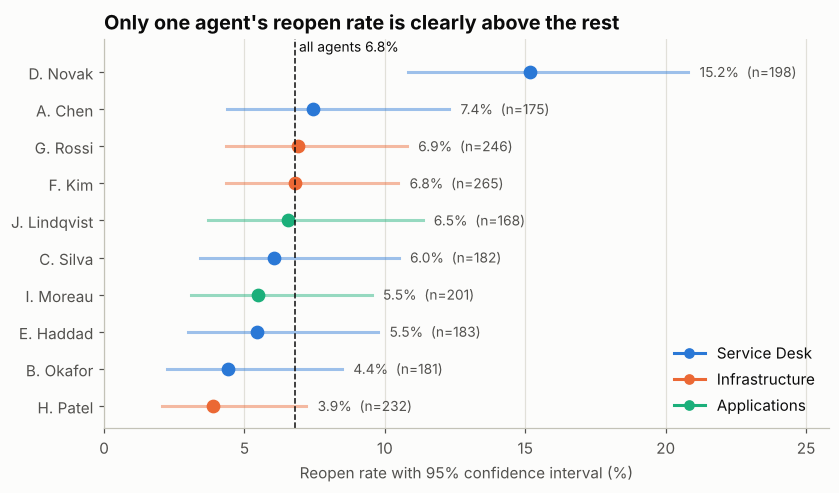

,agent_name,team,tickets,reopened,rate,low,high
0,H. Patel,Infrastructure,232,9,3.9,2.1,7.2
1,B. Okafor,Service Desk,181,8,4.4,2.3,8.5
2,E. Haddad,Service Desk,183,10,5.5,3.0,9.8
3,I. Moreau,Applications,201,11,5.5,3.1,9.5
4,C. Silva,Service Desk,182,11,6.0,3.4,10.5
5,J. Lindqvist,Applications,168,11,6.5,3.7,11.3
6,F. Kim,Infrastructure,265,18,6.8,4.3,10.5
7,G. Rossi,Infrastructure,246,17,6.9,4.4,10.8
8,A. Chen,Service Desk,175,13,7.4,4.4,12.3
9,D. Novak,Service Desk,198,30,15.2,10.8,20.8


In [26]:
agents = df.groupby(["agent_name", "team"]).agg(tickets=("reopened", "size"), reopened=("reopened", "sum")).reset_index()
agents["rate"] = agents.reopened / agents.tickets * 100
intervals = agents.apply(lambda r: kpi.wilson_interval(r.reopened, r.tickets), axis=1, result_type="expand") * 100
agents["low"], agents["high"] = intervals[0], intervals[1]
agents = agents.sort_values("rate").reset_index(drop=True)
overall = df.reopened.mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 4.6))
for y, r in agents.iterrows():
    ax.plot([r.low, r.high], [y, y], color=TEAM_COLOURS[r.team], linewidth=2, alpha=0.45)
    ax.plot(r.rate, y, "o", color=TEAM_COLOURS[r.team], markersize=8)
    ax.text(r.high + 0.4, y, f"{r.rate:.1f}%  (n={r.tickets})", va="center", fontsize=9, color=MUTED)
ax.axvline(overall, color=INK, linewidth=1, linestyle="--")
ax.text(overall + 0.15, len(agents) - 0.45, f"all agents {overall:.1f}%", fontsize=9)
ax.set_yticks(range(len(agents)))
ax.set_yticklabels(agents.agent_name)
ax.set_ylim(-0.6, len(agents) - 0.1)
ax.set_xlim(0, agents.high.max() + 5)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.legend(handles=[plt.Line2D([], [], marker="o", color=c, linewidth=2) for c in TEAM_COLOURS.values()],
          labels=list(TEAM_COLOURS), frameon=False, loc="lower right")
ax.set_xlabel("Reopen rate with 95% confidence interval (%)")
ax.set_title("Only one agent's reopen rate is clearly above the rest")
fig.savefig(IMAGES / "07_reopen_rate_by_agent.png")
plt.show()

agents.round(1)

In [27]:
service_desk = df[df.team == "Service Desk"]
tests = pd.DataFrame({
    "D. Novak reopen rate vs rest of Service Desk":
        kpi.permutation_test(service_desk.reopened, service_desk.agent_name == "D. Novak"),
    "April SLA compliance vs other months":
        kpi.permutation_test(df.sla_met, df.opened_at.dt.month == 4),
    "H. Patel SLA compliance vs rest of Infrastructure":
        kpi.permutation_test(df[df.team == "Infrastructure"].sla_met, df[df.team == "Infrastructure"].agent_name == "H. Patel"),
    "Monday SLA compliance vs other weekdays":
        kpi.permutation_test(df.sla_met, df.opened_weekday == "Monday"),
}).T
tests

,group rate %,rest rate %,difference (points),p-value
D. Novak reopen rate vs rest of Service Desk,15.2,5.8,9.3,0.0001
April SLA compliance vs other months,71.8,76.8,-5.0,0.0503
H. Patel SLA compliance vs rest of Infrastructure,52.6,59.1,-6.5,0.1106
Monday SLA compliance vs other weekdays,74.7,76.4,-1.7,0.4805


In [28]:
# Is D. Novak faster than the rest of the Service Desk? (a possible speed vs quality trade-off)
service_desk.groupby(service_desk.agent_name == "D. Novak").agg(
    tickets=("reopened", "size"), median_hours=("resolution_hours", "median"),
    sla_compliance=("sla_met", "mean"), reopen_rate=("reopened", "mean")).rename(index={True: "D. Novak", False: "Rest of Service Desk"}).round(3)

,tickets,median_hours,sla_compliance,reopen_rate
agent_name,,,,
Rest of Service Desk,721,12.600,0.906,0.058
D. Novak,198,11.875,0.929,0.152


**What this tells us**

- **D. Novak's reopen rate is a real difference.** 30 of 198 tickets were reopened (15.2%, interval 10.8% to 20.8%), against 5.8% for the rest of the Service Desk. No other agent's interval sits clear of the overall 6.8%. In 10,000 shuffles, chance never produced a gap this large (p = 0.0001, the smallest value the test can return). That still holds after allowing for the fact that I picked the highest of 10 agents.
- It does not look like rushing. D. Novak's median resolution time is 11.9 hours against 12.6 hours for the rest of the team, and SLA compliance is similar (92.9% against 90.6%). The cause is not in this data: it could be the ticket mix, how tickets are closed, or training. It is a reason for a conversation and a ticket review, and the data alone does not say what the fix is.
- **The April dip is borderline.** April's compliance was 71.8% against 76.8% in the other months (p = 0.05). With six months to choose from, one month this far out is not surprising. Worth watching, not worth acting on.
- **H. Patel's lower SLA compliance** (52.6% against 59.1% for the rest of Infrastructure, p = 0.11) and **the Monday effect** (74.7% against 76.4%, p = 0.48) are within what chance produces. Naming an agent as an underperformer on that evidence would be unfair.

## Summary

| Question | Answer |
|---|---|
| What does the SLA clock measure? | Elapsed calendar hours. 16.4% of tickets are resolved on a weekend. |
| How long do incidents take? | Median 16.2 h, mean 24.1 h, 90th percentile 51.4 h. The typical ticket meets its target and the slow tail does not. |
| Where does the SLA break? | VPN, Laptop / Hardware and Network Outage, worst at P2 (57% to 66% breached). The ticket mix explains less than 1 point of Infrastructure's gap. |
| How badly do breaches miss? | 35.8% miss by 25% or less. Catching them would lift compliance from 75.9% to 84.5%. |
| Is Infrastructure overloaded? | It carries 2.5x the open tickets per agent, but its breach rate is the same with a short queue as with a long one. |
| Do fixes stick? | The reopen rate (6.8%) is the reliable signal. Repeat contacts are explained by heavy users. |
| Which differences are real? | D. Novak's reopen rate. The April dip, H. Patel's SLA rate and the Monday effect are within chance. |

## Recommendations

1. **Alert at 75% of the SLA target.** 460 tickets were decided within a quarter of their target. This is the cheapest gain, worth up to 8.6 points of compliance.
2. **Review how Infrastructure P2 and P3 tickets are worked before adding headcount.** Breaches do not follow workload, so look at waiting steps first: parts, vendors, access and diagnosis. Start with VPN, which holds 44% of all hours past target.
3. **Prepare for Mondays.** VPN tickets nearly double. Check VPN health before Monday morning and schedule more Infrastructure cover that day.
4. **Report the median and the 90th percentile**, and hours past target, next to the average and the breach count.
5. **Review a sample of D. Novak's reopened tickets** with the agent. The gap is real, and the cause is unknown.
6. **Do not act on single-month or single-agent gaps without a significance check.** Three of the four differences tested here were noise.

## Limitations

- The data is synthetic. The methods are the point, and the specific numbers describe a simulated company.
- The SLA clock here never pauses. Real service desks often measure business hours and pause the clock while waiting for the user.
- There are no ticket status changes or wait reasons, so the notebook can show *that* Infrastructure tickets are slow but not *which step* is slow.
- The permutation tests ask whether a gap is larger than chance. They do not explain what causes it.